In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate the same mock drive cycle from our pipeline for demonstration
time_steps = np.arange(0, 1000, 1)
mock_current = np.where(time_steps % 100 < 50, 2.0, -0.5) 
mock_voltage = 3.2 + np.linspace(1.0, 0.8, 1000) * 1.0 - mock_current * 0.05 + np.random.normal(0, 0.005, 1000)

df = pd.DataFrame({'Time': time_steps, 'Current': mock_current, 'Voltage': mock_voltage})

# Apply simple difference vs. 5-point stencil (from your data_ingestion.py logic)
dt = 1.0
df['dV_dt_simple'] = df['Voltage'].diff() / dt
v = df['Voltage'].values
dvdt_stencil = np.zeros_like(v)
for i in range(2, len(v) - 2):
    dvdt_stencil[i] = (-v[i+2] + 8*v[i+1] - 8*v[i-1] + v[i-2]) / (12 * dt)
df['dV_dt_stencil'] = dvdt_stencil

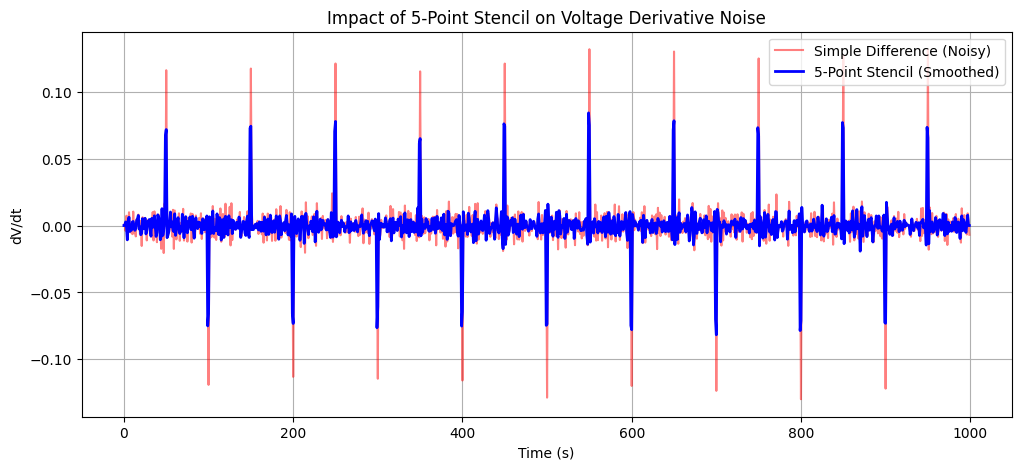

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df['Time'], df['dV_dt_simple'], alpha=0.5, label='Simple Difference (Noisy)', color='red')
plt.plot(df['Time'], df['dV_dt_stencil'], label='5-Point Stencil (Smoothed)', color='blue', linewidth=2)
plt.title('Impact of 5-Point Stencil on Voltage Derivative Noise')
plt.xlabel('Time (s)')
plt.ylabel('dV/dt')
plt.legend()
plt.grid(True)
plt.show()